# Preliminaries

The `pandas` library allows the user several data structures for different data manipulation tasks:
1. Data storage through its `Series` and `DataFrame` data structures.
2. Data filtering using multiple methods from the package.
3. Reading data from many different file formats such as `csv`, `txt`, `xlsx`, ...

Below we provide a brief overview of the `pandas` functionalities needed for these exercises. The complete documentation can be found on the [`pandas` website](https://pandas.pydata.org/).

## Pandas data structures

### Series
The Pandas Series data structure is similar to a one-dimensional array. It can store any type of data. The values are mutable but the size not.

To create `Series`, we call the `pd.Series()` method and pass an array. A `Series` may also be created from a numpy array.

In [ ]:
import pandas as pd
import numpy as np

first_series = pd.Series([1,10,100,1000])

print(first_series)

teams = np.array(['PSV','Ajax','Feyenoord','Twente'])
second_series = pd.Series(teams)

print('\n')
print(second_series)

### DataFrame
One can think of a `DataFrame` as a table with rows and columns (2D structure). The columns can be of a different type (as opposed to `numpy` arrays) and the size of the `DataFrame` is mutable.

To create `DataFrame`, we call the `pd.DataFrame()` method and we can create it from scratch or we can convert a numpy array or a list into a `DataFrame`.

In [ ]:
# DataFrame from scratch
first_dataframe = pd.DataFrame({
    "Position": [1, 2, 3, 4],
    "Team": ['PSV','Ajax','Feyenoord','Twente'],
    "GF": [80, 75, 75, 70],
    "GA": [30, 25, 40, 60],
    "Points": [79, 78, 70, 66]
})

print("From scratch: \n {} \n".format(first_dataframe))

# DataFrme from a list
data = [[1, 2, 3, 4], ['PSV','Ajax','Feyenoord','Twente'], 
        [80, 75, 75, 70], [30, 25, 40, 60], [79, 78, 70, 66]]
columns = ["Position", "Team", "GF", "GA", "Points"]

second_dataframe = pd.DataFrame(data, index=columns)

print("From list: \n {} \n".format(second_dataframe.T)) # the '.T' operator is explained later on

# DataFrame from numpy array
data = np.array([[1, 2, 3, 4], ['PSV','Ajax','Feyenoord','Twente'], 
                 [80, 75, 75, 70], [30, 25, 40, 60], [79, 78, 70, 66]])
columns = ["Position", "Team", "GF", "GA", "Points"]

third_dataframe = pd.DataFrame(data.T, columns=columns)

print("From numpy array: \n {} \n".format(third_dataframe))

### DataFrame attributes
This section gives a quick overview of some of the `pandas.DataFrame` attributes such as `T`, `index`, `columns`, `iloc`, `loc`, `shape` and `values`.

In [ ]:
# transpose the index and columns
print(third_dataframe.T)

In [ ]:
# index makes reference to the row labels
print(third_dataframe.index)

In [ ]:
# columns makes reference to the column labels
print(third_dataframe.columns)

In [ ]:
# iloc allows to access the index by integer-location (e.g. all team names, which are in the second columm)
print(third_dataframe.iloc[:,1])

In [ ]:
# loc allows to access the index by label(s)-location (e.g. all team names, which are in the "Team" columm)
print(third_dataframe.loc[0, 'Team'])

In [ ]:
# shape returns a tuple with the DataFrame dimension, similar to numpy
print(third_dataframe.shape)

In [ ]:
# values return a Numpy representation of the DataFrame data
print(third_dataframe.values)

### DataFrame methods
This section gives a quick overview of some of the `pandas.DataFrame` methods such as `head`, `describe`, `concat`, `groupby`,`rename`, `filter`, `drop` and `isna`. To import data from CSV or MS Excel files, we can make use of `read_csv` and `read_excel`, respectively.

In [ ]:
# print the first few rows in your dataset with head()
print(third_dataframe.head()) # In this case, it is not very useful because we don't have thousands of rows

In [ ]:
# get the summary statistics of the DataFrame with describe()
print(third_dataframe.describe())

In [ ]:
# concatenate (join) DataFrame objects using concat()

# first, we will split the above DataFrame in two different ones
df_a = third_dataframe.loc[[0,1],:]
df_b = third_dataframe.loc[[2,3],:]

print(df_a)
print('\n')

print(df_b)
print('\n')

# now, we concatenate both datasets
df = pd.concat([df_a, df_b])

print(df)

In [ ]:
# group the data by certain variable via groupby()
# here, we have grouped the data by goals for, which in this case is 75

group = df.groupby('GF')

print(group.get_group('75'))

In [ ]:
# rename() helps you change the column or index names
print(df.rename(columns={'Position':'Pos','Team':'Club'}))

In [ ]:
# build a subset of rows or columns of your dataset according to labels via filter()
# here, items refer to the variable names: 'Team' and 'Points'; to select columns, we specify axis=1
print(df.filter(items=['Team', 'Points'], axis=1))

In [ ]:
# dropping some labels
print(df.drop(columns=['GF', 'GA']))

In [ ]:
# search for NA (not available) entries in the DataFrame
print(df.isna()) # No NA values
print('\n')

# create a pandas Series with a NA value
# the Series as W (winnin matches)
tmp = pd.Series([np.NaN, 25, 24, 19],  name="W")

# concatenate the Series with the DataFrame
df = pd.concat([df,tmp], axis = 1)
print(df)
print('\n')

# again, check for NA entries
print(df.isna())

## Dataset

For this week exercises we will use a dataset from the Genomics of Drug Sensitivity in Cancer (GDSC) project (https://www.cancerrxgene.org/). In this study (['Iorio et al., Cell, 2016']()), 265 compounds were tested on 1001 cancer cell lines for which different types of -omics data (RNA expression, DNA methylation, Copy Number Alteration, DNA sequencing) are available. This is a valuable resource to look for biomarkers of drugs sensitivity in order to try to understand why cancer patients responds very differently to cancer drugs and find ways to assign the optimal treatment to each patient.

For this exercise we will use a subset of the data, focusing the response to the drug YM155 (Sepantronium bromide) on four cancer types, for a total of 148 cancer cell lines.

| ID          | Cancer type                      |
|-------------|----------------------------------|
|   COAD/READ | Colorectal adenocarcinoma        |
|   NB        | Neuroblastoma                    |
|   KIRC      | Kidney renal clear cell carcinoma|
|   BRCA      | Breast carcinoma                 |

We will use the RNA expression data (RMA normalised). Only genes with high variability across cell lines (variance > 5, resulting in 238 genes) have been kept.

Drugs have been tested at different concentration, measuring each time the viability of the cells. Drug sensitivity is measured using the natural log of the fitted IC50 metric, which is defined as the half maximal inhibitory concentration. A lower IC50 corresponds to a more sensitive cell line because a lower amount of drug is sufficient to have a strong response, while a higher IC50 corresponds to a more resistant cell line because more drug is needed for killing the cells.

Based on the IC50 metric, cells can be classified as sensitive or resistant. The classification is done by computing the $z$-score across all cell lines in the GDSC for each drug, and considering as sensitive the ones with $z$-score < 0 and resistant the ones with $z$-score > 0.

The dataset is originally provided as 3 files ([original source](https://www.sciencedirect.com/science/article/pii/S0092867416307462?via%3Dihub)) :

`GDSC_RNA_expression.csv`: gene expression matrix with the cell lines in the rows (148) and the genes in the columns (238).

`GDSC_drug_response.csv`: vector with the cell lines response to the drug YM155 in terms of log(IC50) and as classification in sensitive or resistant.

`GDSC_metadata.csv`: metadata for the 148 cell lines including name, COSMIC ID and tumor type (using the classification from ['The Cancer Genome Atlas TCGA'](https://www.cancer.gov/about-nci/organization/ccg/research/structural-genomics/tcga))

For convenience, we provide the data already curated.

`RNA_expression_curated.csv`: [148 cell lines , 238 genes]

`drug_response_curated.csv`: [148 cell lines , YM155 drug]

The curated data cam be read as `pandas` `DataFrame`s in the following way:

In [2]:
import pandas as pd

# gene_expression = pd.read_csv("./data/RNA_expression_curated.csv", sep=',', header=0, index_col=0)
# drug_response = pd.read_csv("./data/drug_response_curated.csv", sep=',', header=0, index_col=0)
gene_expression = pd.read_csv('.\data\RNA_expression_curated.csv', sep=',', header=0, index_col=0)
drug_response = pd.read_csv('.\data\drug_response_curated.csv', sep=',', header=0, index_col=0)

In [ ]:
print(gene_expression.shape)
print(drug_response.shape)

You can use the `DataFrame`s directly as inputs to the the `sklearn` models. The advantage over using `numpy` arrays is that the variable are annotated, i.e. each input and output has a name.

## Tools
The `scikit-learn` library provides the required tools for linear regression/classification and shrinkage, as well as for logistic regression.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import LogisticRegression

Note that the notation used for the hyperparameters in the `scikit-learn` library is different from the one used in the lecture. More specifically, in the lecture $\alpha$ is the tunable parameter to select the compromise between Ridge and Lasso. Whereas, `scikit-learn` library refers to `alpha` as the tunable parameter $\lambda$. Please check the documentation for more details.

# Exercises

## Selection of the hyperparameter

Implement cross-validation (using `sklearn.grid_search.GridSearchCV`) to select the `alpha` hyperparameter of `sklearn.linear_model.Lasso`. 


## Feature selection

Look at the features selected using the hyperparameter which corresponds to the minimum cross-validation error.

<p><font color='#770a0a'>Is the partition in training and validation sets playing a role in the selection of the hyperparameter? How will this affect the selection of the relevant features?</font></p>

<p><font color='#770a0a'>Should the value of the intercept also be shrunk to zero with Lasso and Ridge regression? Motivate your answer.</font></p>


## Bias-variance 

Show the effect of the regularization on the parameter estimates in terms of bias and variance. For this you can repeat the optimization 100 times using bootstrap and visualise the profile of the Lasso regression coefficient over a grid of the hyperparameter, optionally including the variability as error bars.

<p><font color='#770a0a'>Based on the visual analysis of the plot, what are your observation on bias and variance in relation to model complexity? Motivate your answer.</font></p>


## Logistic regression

<p><font color='#770a0a'>Write the expression of the objective function for the penalized logistic regression with $L_1$ and $L_2$ regularisation (as in Elastic net).</font></p>

## Selection of the hyperparameter


In [ ]:
gene_expression.head()

In [ ]:
drug_response.head()

In [ ]:
from sklearn.model_selection import GridSearchCV
import numpy as np

X = gene_expression.values
y = drug_response['YM155'].values

model = Lasso(max_iter=5000)

parameter_grid = {
    "alpha": np.logspace(-5,1,20)
}

grid = GridSearchCV(
    estimator=model,
    param_grid=parameter_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X,y)

print("best alpha", grid.best_params_["alpha"])
print("best cv score", grid.best_score_)

## Feature selection


In [ ]:
best_model = grid.best_estimator_

coefs = best_model.coef_

selected_genes = pd.Series(coefs, index=gene_expression.columns)

selected_genes = selected_genes[selected_genes != 0]

print("genes relevant predictors of YM155 response at the chosen regularization strength")
print("Number of selected genes:", len(selected_genes))
print(selected_genes.sort_values(ascending=False).head(15))  


### Role of partitioning: 


The train and validation partition play an important role in hyperparameter selection. Cross validation splits the data into different train & validation folds. The error estimate for each alpha depends on these partitions. Different folds can lead into different best alphas. 

Lasso sets some gene coefficients set to zero and keep others. Here when we use cross validation as mentioned above the best value of alpha may change a little everytime which will cause lasso to keep different sets of genes. 

### Shrinking the intercept:

The intercept is basically the value of $\hat{y}$ when all the other features are set to zerp and it shifts the regression line up or down. Making it go to zero doesn't really have any meaning. For coeeficeitns making the zero makes sense since it makes the model less complex and remove the non important features but intercept doesn't have this impact so it shouldn't be shrunk.

## Bias-Variance

When alpha is low there is a high variance. the coefficients are deviating from zero and contributing to the model, causing a low bias. With an increasing alpha the contribution of coefficients decrease and the variance does so as well, causing a rising bias up until an alpha of 1, where the coefficients are all (almost set to 0) causing very low to no variance with a high bias.

C:\Users\20212287\ANACONDAREINSTALL\envs\8DM50\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:532: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.13463696822287197, tolerance: 0.09397394558558558
  positive)


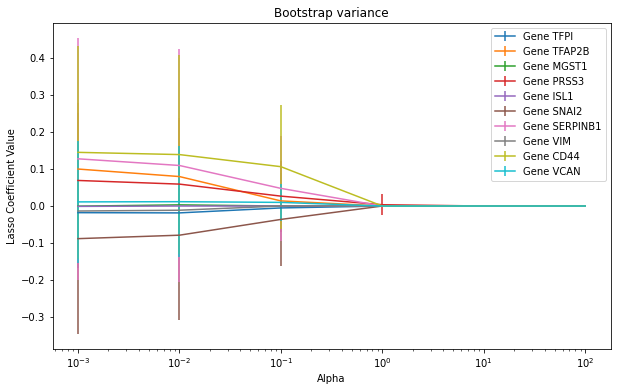

In [3]:
from sklearn.utils import resample
import numpy as np
import pandas as pd
from sklearn.utils import resample
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
import sklearn

data_DR = drug_response
data_GE = gene_expression
X_train, X_test, y_train, y_test = train_test_split(data_GE, data_DR['YM155'])#, test_size = 0.3)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #scale only x data

alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
number_bootstrap = 100

#create a dictionary to store bootstrap values per alpha value
#This way mean and variance can be stored and accessed again.
coef_bootstrap = {alpha_value: [] for alpha_value in alpha_list}
#coef_bootstrap = {}
for i in range(number_bootstrap):
    X_boot, y_boot = resample(X_train_scaled, y_train, replace = True)
    for alpha_value in alpha_list:
        lasso = Lasso(alpha=alpha_value, max_iter = 30000) #below this max_iter sometimes warning objective didn't converge (happens more often with lower values of iterations)
        lasso.fit(X_boot, y_boot)
        coef_bootstrap[alpha_value].append(lasso.coef_)

for alpha_value in alpha_list:
    coef_bootstrap[alpha_value] = np.array(coef_bootstrap[alpha_value])
        

mean_coefs = [coef_bootstrap[alpha].mean(axis=0) for alpha in alpha_list]
std_coefs = [coef_bootstrap[alpha].std(axis=0) for alpha in alpha_list]

#select a few genes to depict in the figures
genes = X_train.columns
selected_genes = []

num_genes_depict = 10 #mention number of genes to depict
for q in range(num_genes_depict):
    selected_genes.append(q)

plt.figure(figsize=(10, 6))
for g in selected_genes:
    plt.errorbar(alpha_list, [mean[g] for mean in mean_coefs], [std[g] for std in std_coefs], label=f'Gene {genes[g]}')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Lasso Coefficient Value')
plt.title('Bootstrap variance')
plt.legend()
plt.show()
    

## Logistic regression

The objective function for normal logistic regression is maximizing the log likelihood function defined as:
$$Max_B\{\sum_{i=1}^N\{y_iB^Tx_i-log(1-e^{B^Tx_i})\}\}$$

Two common ways to penalize regression models are L1 and L2 regularisation.

L1 regularisation adds an extra term to the objective function which penalizes the sum of the absolute value of the coefficients defined as $L_1 = \lambda\sum_{j=1}^p|B_j|$

L2 regularisation adds an extra term to the objective function which penalizes the sum of squares of the coefficients defined as $L_2 = \lambda\sum_{j=1}^pB_j^2$

If we penalize logistic regression with both L1 and L2 regularisation as done in Elastic Net we arrive at the following objective function:
$$Max_B\{\sum_{i=1}^N\{y_i(B_0+B^Tx_i)-log(1-e^{(B_0+B^Tx_i)})\} + \lambda \sum_{j=1}^p(\alpha B_j^2+(1-\alpha)|B_j|)\}$$
Where $\alpha$ is a tunable parameter between 0 (L1) and 1 (L2). 
Note that the intercept is not used in the L1 and L2 regularisation 